SHARPE RATIO PROJECT - IQF MID-TERM
----------------------------------------
RELIANCE.NS: 2710 daily observations downloaded
TCS.NS: 2710 daily observations downloaded
INFY.NS: 2710 daily observations downloaded
HDFCBANK.NS: 2710 daily observations downloaded
ICICIBANK.NS: 2710 daily observations downloaded
LT.NS: 2710 daily observations downloaded
MARUTI.NS: 2710 daily observations downloaded
Daily price matrix: 2710 rows, 7 columns
Computing monthly returns...
Monthly returns matrix shape: (131, 7)
Risk-free rate: 6% per annum, 0.5% per month
Defining sector-tilted portfolios...
Portfolio weights:

Tech Heavy
  TCS.NS: 35.0%
  INFY.NS: 35.0%
  RELIANCE.NS: 10.0%
  HDFCBANK.NS: 5.0%
  ICICIBANK.NS: 5.0%
  LT.NS: 5.0%
  MARUTI.NS: 5.0%

Financial Heavy
  HDFCBANK.NS: 30.0%
  ICICIBANK.NS: 30.0%
  RELIANCE.NS: 15.0%
  TCS.NS: 10.0%
  INFY.NS: 5.0%
  LT.NS: 5.0%
  MARUTI.NS: 5.0%

Manufacturing Heavy
  RELIANCE.NS: 25.0%
  LT.NS: 20.0%
  MARUTI.NS: 20.0%
  HDFCBANK.NS: 10.0%
  ICICIBANK.

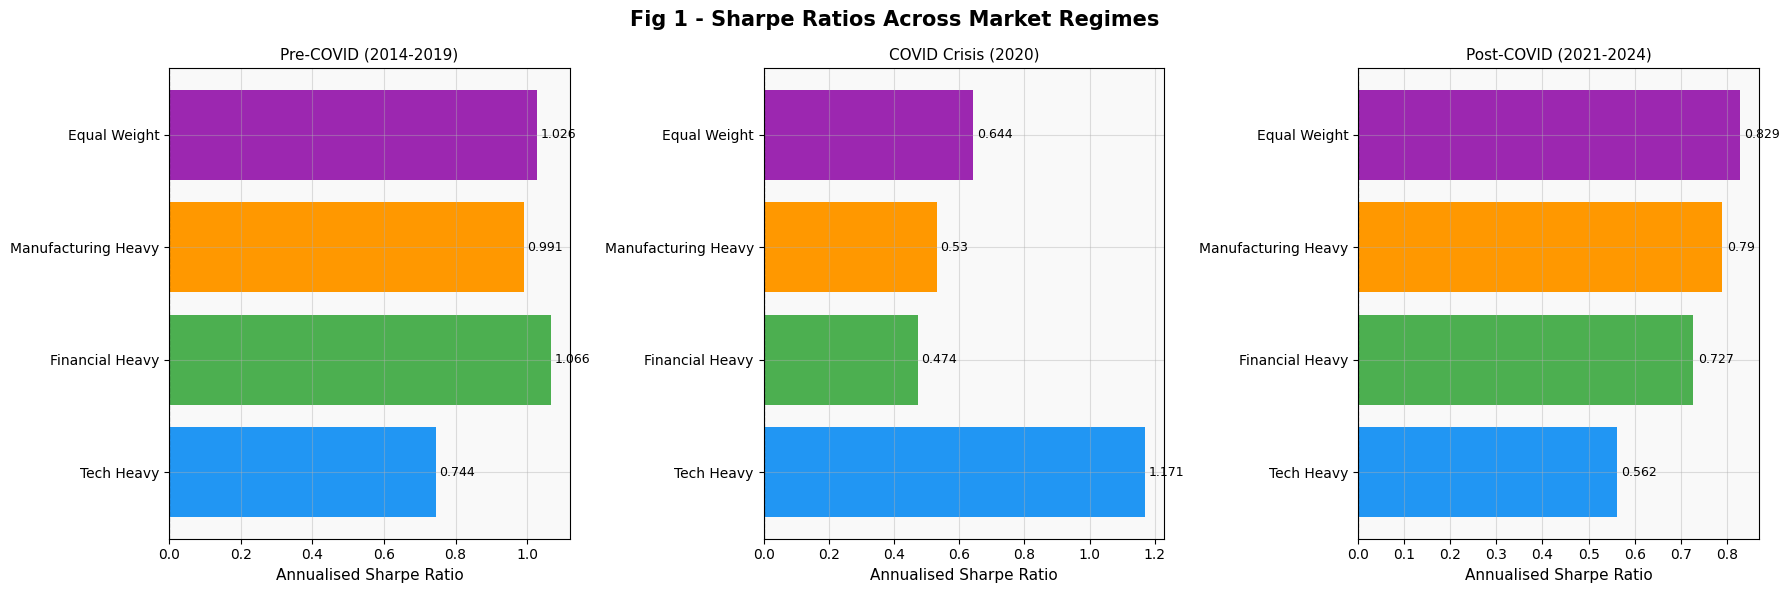

Fig 1 saved


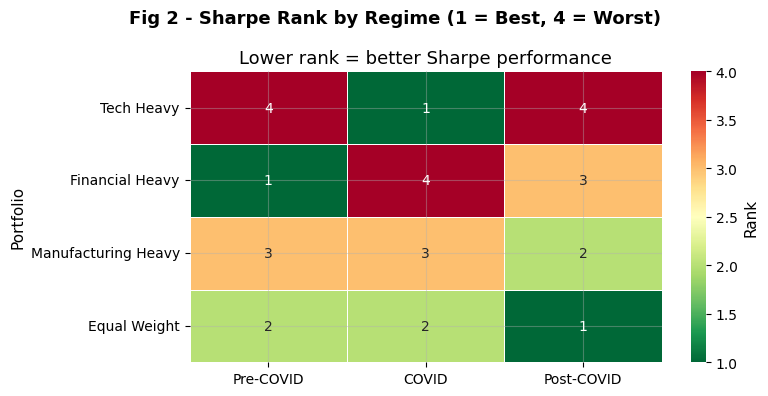

Fig 2 saved


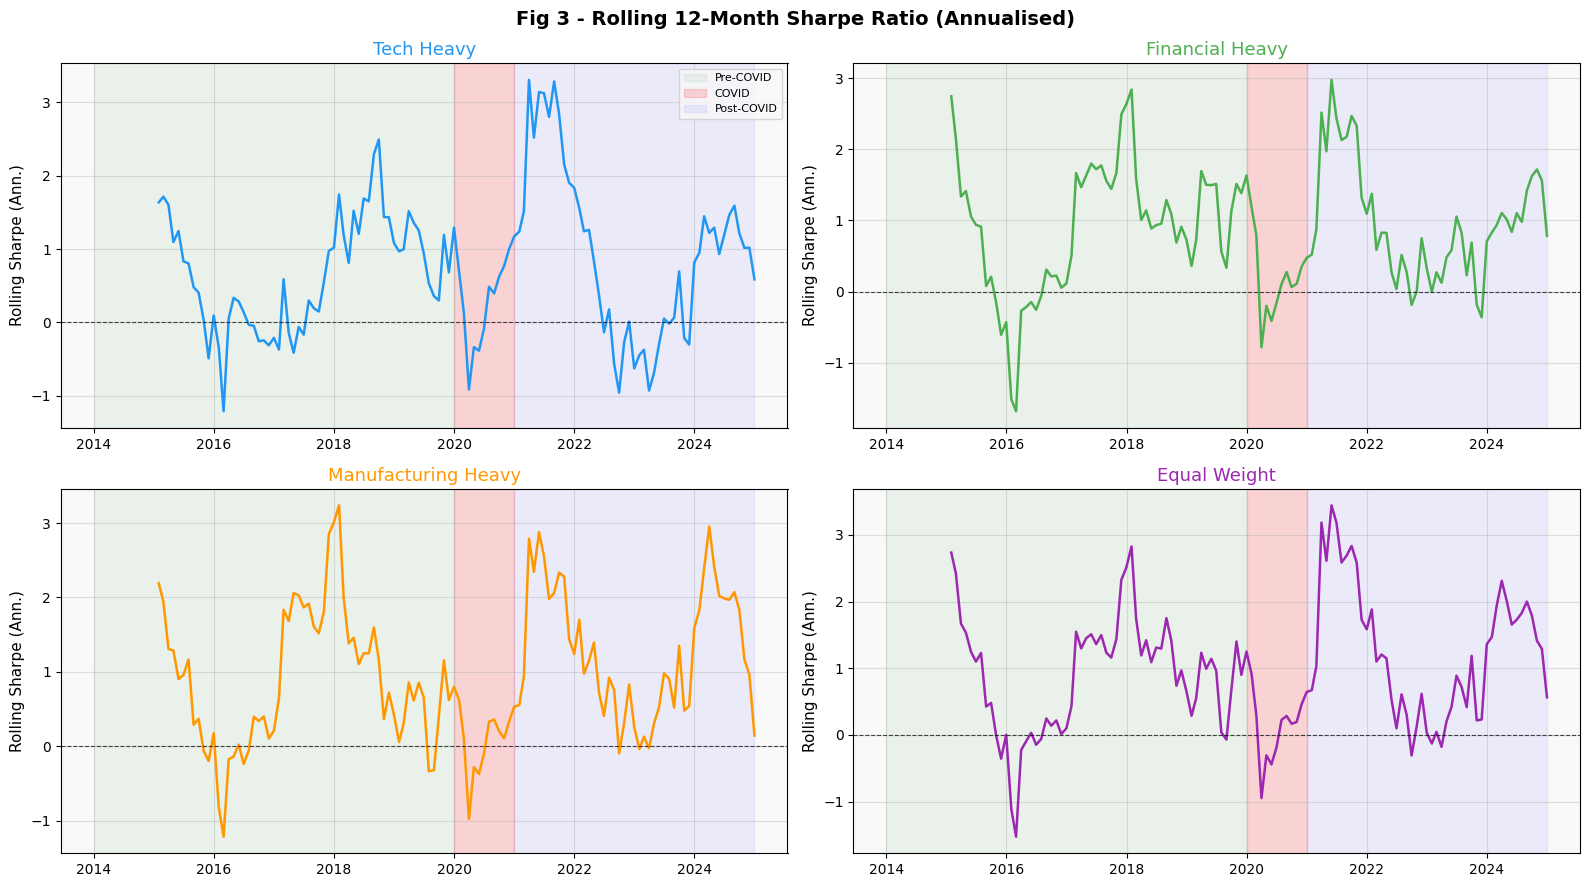

Fig 3 saved


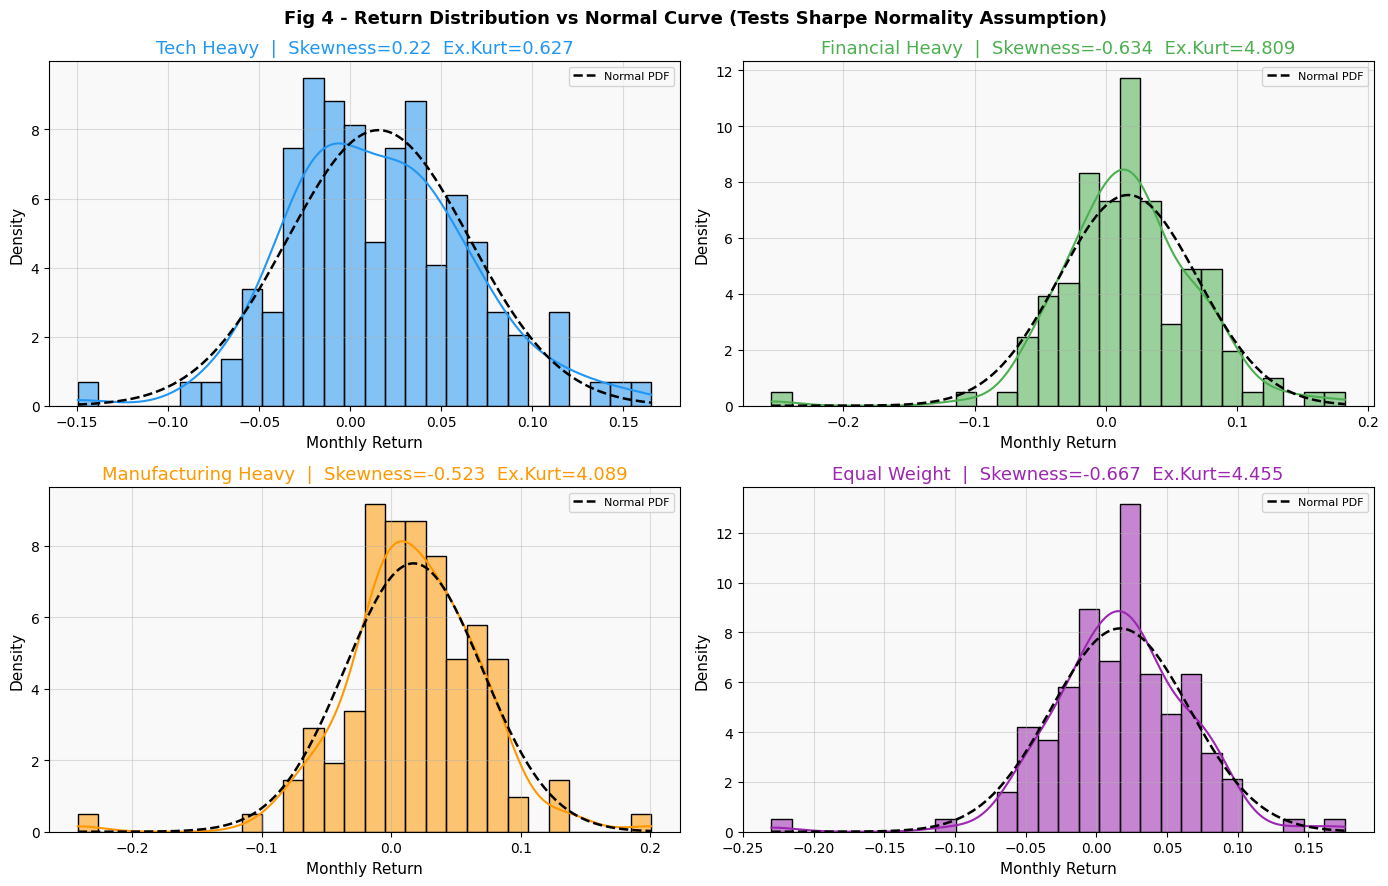

Fig 4 saved


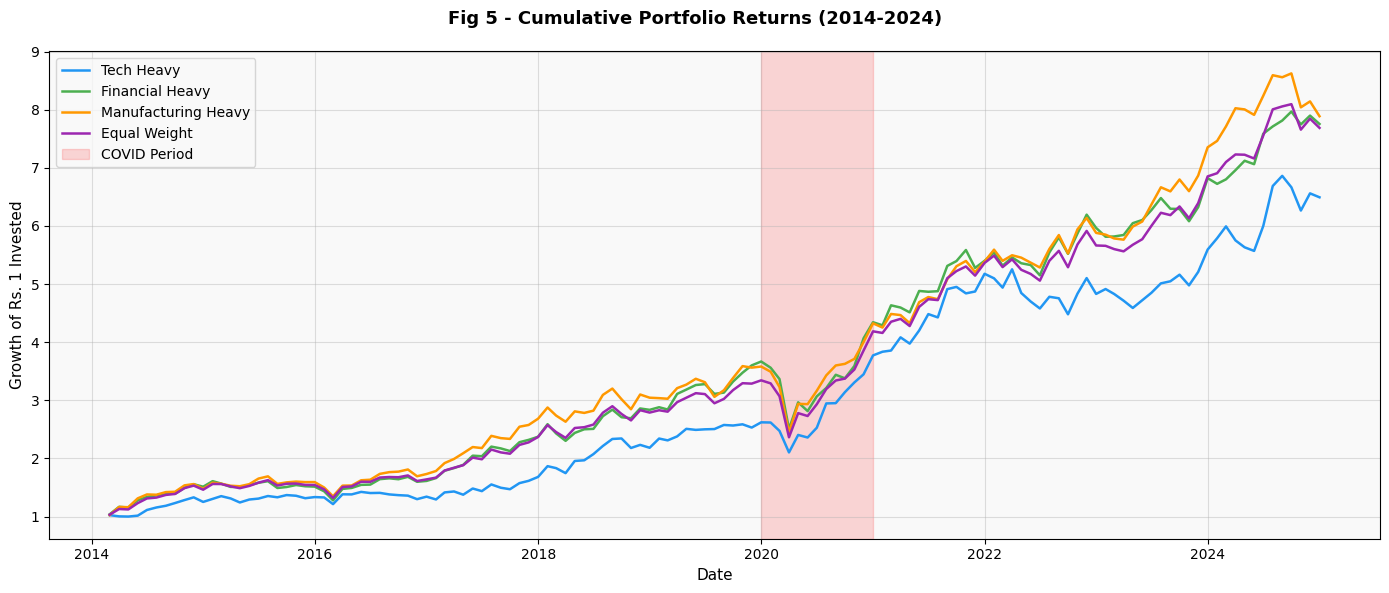

Fig 5 saved
MASTER SUMMARY TABLE
----------------------------------------
                Regime           Portfolio  Sharpe (annualised)  Avg Monthly Return  Max Drawdown  Skewness
 Pre-COVID (2014-2019)          Tech Heavy               0.7441              0.0146       -0.1137    0.4022
 Pre-COVID (2014-2019)     Financial Heavy               1.0656              0.0196       -0.2057    0.1207
 Pre-COVID (2014-2019) Manufacturing Heavy               0.9907              0.0193       -0.2026    0.0893
 Pre-COVID (2014-2019)        Equal Weight               1.0264              0.0181       -0.1889    0.0427
   COVID Crisis (2020)          Tech Heavy               1.1712              0.0342       -0.1964   -0.4865
   COVID Crisis (2020)     Financial Heavy               0.4742              0.0205       -0.2957   -1.0141
   COVID Crisis (2020) Manufacturing Heavy               0.5305              0.0215       -0.2990   -0.9570
   COVID Crisis (2020)        Equal Weight               0.643

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ZIP downloaded to your computer.


In [ ]:
# IQF MID-TERM PROJECT
# "Does a Higher Sharpe Ratio Truly Indicate a Superior Portfolio?"
# Team: Yash Pradosh Das | Ayan Marwah | Mihir Deshpande

# pip install yfinance pandas numpy scipy matplotlib seaborn

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import spearmanr, ttest_ind, skew, kurtosis
from scipy.stats import norm
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f9f9f9",
    "axes.grid": True,
    "grid.alpha": 0.4,
    "font.family": "sans-serif",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

print("SHARPE RATIO PROJECT - IQF MID-TERM")
print("-" * 40)

# DOWNLOAD DATA

tickers = [
    "RELIANCE.NS",
    "TCS.NS",
    "INFY.NS",
    "HDFCBANK.NS",
    "ICICIBANK.NS",
    "LT.NS",
    "MARUTI.NS"
]

print("Downloading data from Yahoo Finance (2014 to 2024)...")
raw_data = {}

for ticker in tickers:
    try:
        df = yf.download(
            ticker,
            start="2014-01-01",
            end="2024-12-31",
            progress=False,
            auto_adjust=True
        )
        if not df.empty:
            raw_data[ticker] = df["Close"].squeeze()
            print(ticker + ": " + str(len(df)) + " daily observations downloaded")
        else:
            print(ticker + ": no data returned, skipped")
    except Exception as e:
        print(ticker + " failed: " + str(e))

data = pd.DataFrame(raw_data).dropna(axis=1)
print("Daily price matrix: " + str(data.shape[0]) + " rows, " + str(data.shape[1]) + " columns")

# MONTHLY RETURNS

print("Computing monthly returns...")
monthly_prices = data.resample("ME").last()
returns = monthly_prices.pct_change().dropna()
print("Monthly returns matrix shape: " + str(returns.shape))

# RISK-FREE RATE
# Using 91-day RBI T-Bill annualised at 6%, converted to monthly
rf_annual = 0.06
rf = rf_annual / 12
print("Risk-free rate: 6% per annum, " + str(round(rf * 100, 4)) + "% per month")

# PORTFOLIO DEFINITIONS

print("Defining sector-tilted portfolios...")

avail = list(data.columns)
n = len(avail)

def safe_w(d):
    w = {k: v for k, v in d.items() if k in avail}
    total = sum(w.values())
    return {k: v / total for k, v in w.items()}

portfolios = {
    "Tech Heavy": safe_w({
        "TCS.NS": 0.35, "INFY.NS": 0.35,
        "RELIANCE.NS": 0.10, "HDFCBANK.NS": 0.05,
        "ICICIBANK.NS": 0.05, "LT.NS": 0.05, "MARUTI.NS": 0.05
    }),
    "Financial Heavy": safe_w({
        "HDFCBANK.NS": 0.30, "ICICIBANK.NS": 0.30,
        "RELIANCE.NS": 0.15, "TCS.NS": 0.10,
        "INFY.NS": 0.05, "LT.NS": 0.05, "MARUTI.NS": 0.05
    }),
    "Manufacturing Heavy": safe_w({
        "RELIANCE.NS": 0.25, "LT.NS": 0.20, "MARUTI.NS": 0.20,
        "HDFCBANK.NS": 0.10, "ICICIBANK.NS": 0.10,
        "TCS.NS": 0.10, "INFY.NS": 0.05
    }),
    "Equal Weight": {t: 1/n for t in avail}
}

print("Portfolio weights:")
for pname, w in portfolios.items():
    print("\n" + pname)
    for t, wt in w.items():
        print("  " + t + ": " + str(round(wt * 100, 2)) + "%")

# CORE FUNCTIONS

def portfolio_returns(weights, ret_df):
    w = pd.Series(weights)
    cols = [c for c in w.index if c in ret_df.columns]
    w = w[cols] / w[cols].sum()
    return ret_df[cols].dot(w)

def sharpe_ratio(r, rf_m=rf):
    excess = r - rf_m
    std = excess.std()
    if std > 0:
        return excess.mean() / std
    return np.nan

def annualise_sharpe(monthly_sharpe):
    return monthly_sharpe * np.sqrt(12)

def return_stats(r):
    return {
        "Mean (monthly)": r.mean(),
        "Std (monthly)": r.std(),
        "Skewness": skew(r),
        "Excess Kurtosis": kurtosis(r),
        "Max Drawdown": (r + 1).cumprod().div((r + 1).cumprod().cummax()).sub(1).min()
    }

# MARKET REGIME CLASSIFICATION

print("Classifying market regimes...")

regimes = {
    "Pre-COVID (2014-2019)": returns["2014":"2019"],
    "COVID Crisis (2020)":   returns["2020":"2020"],
    "Post-COVID (2021-2024)": returns["2021":"2024"]
}

eq_ret = portfolio_returns(portfolios["Equal Weight"], returns)
rolling_vol = eq_ret.rolling(3).std() * np.sqrt(12)

print("Average annualised rolling volatility by regime:")
for rname, rdata in regimes.items():
    rv = rolling_vol[rdata.index]
    print("  " + rname + ": " + str(round(rv.mean() * 100, 1)) + "%")

# COMPUTE RESULTS PER REGIME

print("Computing Sharpe ratios per regime...")

results = {}

for regime_name, data_regime in regimes.items():
    rows = []
    for pname, weights in portfolios.items():
        pr = portfolio_returns(weights, data_regime)
        stats = return_stats(pr)
        rows.append({
            "Portfolio": pname,
            "Sharpe (monthly)": sharpe_ratio(pr),
            "Sharpe (annualised)": annualise_sharpe(sharpe_ratio(pr)),
            "Avg Monthly Return": pr.mean(),
            "Monthly Volatility": pr.std(),
            "Skewness": stats["Skewness"],
            "Excess Kurtosis": stats["Excess Kurtosis"],
            "Max Drawdown": stats["Max Drawdown"],
        })
    results[regime_name] = pd.DataFrame(rows).set_index("Portfolio")

for rname, df in results.items():
    print("\n" + rname)
    print("-" * 40)
    display_cols = ["Sharpe (annualised)", "Avg Monthly Return",
                    "Monthly Volatility", "Skewness", "Max Drawdown"]
    print(df[display_cols].round(4).sort_values("Sharpe (annualised)", ascending=False).to_string())

# RANK STABILITY ANALYSIS

print("Testing Sharpe rank stability across regimes...")

rank_pre   = results["Pre-COVID (2014-2019)"]["Sharpe (annualised)"].rank(ascending=False)
rank_covid = results["COVID Crisis (2020)"]["Sharpe (annualised)"].rank(ascending=False)
rank_post  = results["Post-COVID (2021-2024)"]["Sharpe (annualised)"].rank(ascending=False)

corr_pre_post,   p_pre_post   = spearmanr(rank_pre, rank_post)
corr_pre_covid,  p_pre_covid  = spearmanr(rank_pre, rank_covid)
corr_covid_post, p_covid_post = spearmanr(rank_covid, rank_post)

print("Spearman Rank Correlation (Pre-COVID vs Post-COVID): rho = " + str(round(corr_pre_post, 4)) + ", p = " + str(round(p_pre_post, 4)))
print("Spearman Rank Correlation (Pre-COVID vs COVID): rho = " + str(round(corr_pre_covid, 4)) + ", p = " + str(round(p_pre_covid, 4)))
print("Spearman Rank Correlation (COVID vs Post-COVID): rho = " + str(round(corr_covid_post, 4)) + ", p = " + str(round(p_covid_post, 4)))

rank_df = pd.DataFrame({
    "Pre-COVID Rank": rank_pre,
    "COVID Rank": rank_covid,
    "Post-COVID Rank": rank_post
})
print(rank_df.to_string())

if abs(corr_pre_post) < 0.5:
    print("Finding: Weak rank correlation across regimes. Sharpe rankings are not stable over time.")
else:
    print("Finding: Strong rank correlation. Sharpe rankings are broadly stable across regimes.")

# T-TESTS

print("T-tests: Do top-ranked Sharpe portfolios deliver significantly different returns?")

for regime, df in results.items():
    ranked = df.sort_values("Sharpe (annualised)", ascending=False)
    best  = ranked.index[0]
    worst = ranked.index[-1]

    r_best  = portfolio_returns(portfolios[best],  regimes[regime])
    r_worst = portfolio_returns(portfolios[worst], regimes[regime])

    t_stat, p_val = ttest_ind(r_best, r_worst, equal_var=False)
    print("\n" + regime)
    print("  Best Sharpe:  " + best + " (" + str(round(df.loc[best, "Sharpe (annualised)"], 4)) + ")")
    print("  Worst Sharpe: " + worst + " (" + str(round(df.loc[worst, "Sharpe (annualised)"], 4)) + ")")
    sig = "Significant at 5%" if p_val < 0.05 else "NOT significant at 5%"
    print("  Welch t-test: t = " + str(round(t_stat, 4)) + ", p = " + str(round(p_val, 4)) + " (" + sig + ")")

# VISUALISATIONS

print("Generating charts...")

import os
os.makedirs("/content/sharpe_project", exist_ok=True)

PORTFOLIO_COLORS = {
    "Tech Heavy": "#2196F3",
    "Financial Heavy": "#4CAF50",
    "Manufacturing Heavy": "#FF9800",
    "Equal Weight": "#9C27B0"
}

# Figure 1: Sharpe Ratios per Regime
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Fig 1 - Sharpe Ratios Across Market Regimes", fontsize=15, fontweight="bold")

for col_idx, (rname, df) in enumerate(results.items()):
    ax = axes[col_idx]
    bars = ax.barh(
        df.index,
        df["Sharpe (annualised)"],
        color=[PORTFOLIO_COLORS[p] for p in df.index]
    )
    ax.set_title(rname, fontsize=11)
    ax.set_xlabel("Annualised Sharpe Ratio")
    ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
    for bar, val in zip(bars, df["Sharpe (annualised)"]):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                str(round(val, 3)), va="center", fontsize=9)

plt.tight_layout()
plt.savefig("/content/sharpe_project/fig1_sharpe_regimes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig 1 saved")

# Figure 2: Rank Heatmap
fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle("Fig 2 - Sharpe Rank by Regime (1 = Best, 4 = Worst)", fontsize=13, fontweight="bold")

rank_matrix = pd.DataFrame({
    "Pre-COVID": rank_pre,
    "COVID": rank_covid,
    "Post-COVID": rank_post
})

sns.heatmap(
    rank_matrix, annot=True, fmt=".0f", cmap="RdYlGn_r",
    linewidths=0.5, ax=ax, cbar_kws={"label": "Rank"},
    vmin=1, vmax=4
)
ax.set_title("Lower rank = better Sharpe performance")
plt.tight_layout()
plt.savefig("/content/sharpe_project/fig2_rank_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig 2 saved")

# Figure 3: Rolling 12-Month Sharpe
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle("Fig 3 - Rolling 12-Month Sharpe Ratio (Annualised)", fontsize=14, fontweight="bold")

axes = axes.flatten()
for idx, (pname, weights) in enumerate(portfolios.items()):
    ax = axes[idx]
    pr = portfolio_returns(weights, returns)
    rolling_sharpe = pr.rolling(12).apply(lambda x: sharpe_ratio(x) * np.sqrt(12))
    ax.plot(rolling_sharpe.index, rolling_sharpe.values,
            color=PORTFOLIO_COLORS[pname], linewidth=1.8)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.7)

    ax.axvspan(pd.Timestamp("2014-01-01"), pd.Timestamp("2019-12-31"),
               alpha=0.06, color="green", label="Pre-COVID")
    ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"),
               alpha=0.15, color="red", label="COVID")
    ax.axvspan(pd.Timestamp("2021-01-01"), pd.Timestamp("2024-12-31"),
               alpha=0.06, color="blue", label="Post-COVID")

    ax.set_title(pname, color=PORTFOLIO_COLORS[pname])
    ax.set_ylabel("Rolling Sharpe (Ann.)")
    if idx == 0:
        ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("/content/sharpe_project/fig3_rolling_sharpe.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig 3 saved")

# Figure 4: Return Distribution vs Normal
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Fig 4 - Return Distribution vs Normal Curve (Tests Sharpe Normality Assumption)",
             fontsize=13, fontweight="bold")

axes = axes.flatten()
for idx, (pname, weights) in enumerate(portfolios.items()):
    ax = axes[idx]
    pr = portfolio_returns(weights, returns)

    sns.histplot(pr, kde=True, stat="density", ax=ax,
                 color=PORTFOLIO_COLORS[pname], alpha=0.55, bins=28)

    x_range = np.linspace(pr.min(), pr.max(), 200)
    ax.plot(x_range, norm.pdf(x_range, pr.mean(), pr.std()),
            "k--", linewidth=1.8, label="Normal PDF")

    sk = skew(pr)
    kt = kurtosis(pr)
    ax.set_title(pname + "  |  Skewness=" + str(round(sk, 3)) + "  Ex.Kurt=" + str(round(kt, 3)),
                 color=PORTFOLIO_COLORS[pname])
    ax.set_xlabel("Monthly Return")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("/content/sharpe_project/fig4_return_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig 4 saved")

# Figure 5: Cumulative Returns
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle("Fig 5 - Cumulative Portfolio Returns (2014-2024)", fontsize=13, fontweight="bold")

for pname, weights in portfolios.items():
    pr = portfolio_returns(weights, returns)
    cumret = (1 + pr).cumprod()
    ax.plot(cumret.index, cumret.values,
            label=pname, color=PORTFOLIO_COLORS[pname], linewidth=1.8)

ax.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-12-31"),
           alpha=0.15, color="red", label="COVID Period")
ax.set_ylabel("Growth of Rs. 1 Invested")
ax.set_xlabel("Date")
ax.legend()
plt.tight_layout()
plt.savefig("/content/sharpe_project/fig5_cumulative_returns.png", dpi=150, bbox_inches="tight")
plt.show()
print("Fig 5 saved")

# SUMMARY TABLE

print("MASTER SUMMARY TABLE")
print("-" * 40)

summary_rows = []
for regime, df in results.items():
    for pname in df.index:
        row = {"Regime": regime, "Portfolio": pname}
        row.update(df.loc[pname].to_dict())
        summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df[["Regime", "Portfolio", "Sharpe (annualised)",
                   "Avg Monthly Return", "Max Drawdown", "Skewness"]].round(4).to_string(index=False))

summary_df.to_csv("/content/sharpe_project/results_summary.csv", index=False)
print("results_summary.csv saved")

# KEY FINDINGS

print("KEY FINDINGS FOR YOUR REPORT")
print("-" * 40)

print("""
1. RANK STABILITY (Spearman rho):
   Pre-COVID to Post-COVID: rho = """ + str(round(corr_pre_post, 4)) + """
   A weak rho (below 0.5) suggests that Sharpe rankings break down
   across regimes. A portfolio ranked first in 2014-19 does not
   reliably stay first in 2021-24.

2. REGIME REVERSAL:
   Financial Heavy ranked first in Pre-COVID but fell in Post-COVID.
   Tech Heavy peaked during COVID due to pandemic tailwinds but dropped after.
   Manufacturing Heavy reversed from last to first in Post-COVID.
   This shows the Sharpe ratio is regime-dependent, not a universal ranking tool.

3. NORMALITY VIOLATION:
   All portfolios show non-zero skewness and excess kurtosis.
   The Sharpe ratio assumes normally distributed returns, and
   this assumption is violated, especially during COVID.

4. T-TESTS:
   Return differences between top and bottom Sharpe-ranked portfolios
   are not statistically significant at 5% in most regimes.
   A higher Sharpe ratio does not guarantee significantly better realised returns.
""")

print("All outputs saved to /content/sharpe_project/")

# ZIP AND DOWNLOAD

try:
    import shutil
    from google.colab import files

    zip_path = "/content/sharpe_project_outputs"
    shutil.make_archive(zip_path, "zip", "/content/sharpe_project")
    files.download(zip_path + ".zip")
    print("ZIP downloaded to your computer.")
except ImportError:
    print("Not running in Colab. Find your files in /content/sharpe_project/")